<a href="https://colab.research.google.com/github/aditya27you/Movie-Data-Analysis/blob/main/Netflixmovie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving moviedta2025.csv to moviedta2025.csv
User uploaded file "moviedta2025.csv" with length 1617815 bytes


In [6]:
# Load the uploaded CSV file into a pandas DataFrame
df = pd.read_csv('moviedta2025.csv')

# Now df is defined, and df.head() will work
display(df.head())

,show_id,Title,Director,Release_date,Rating,genres,popularity,vote_count,vote_average,budget,revenue
0,10192,Shrek Forever After,Mike Mitchell,16-05-2010,6.380,"Comedy, Adventure, Fantasy, Animation, Family",203.893,7449,6.380,165000000,752600867
1,27205,Inception,Christopher Nolan,15-07-2010,8.369,"Action, Science Fiction, Adventure",156.242,37119,8.369,160000000,839030630
2,12444,Harry Potter and the Deathly Hallows: Part 1,David Yates,17-11-2010,7.744,"Adventure, Fantasy",121.191,19327,7.744,250000000,954305868
3,38757,Tangled,"Byron Howard, Nathan Greno",24-11-2010,7.600,"Animation, Family, Adventure",111.762,11638,7.600,260000000,592461732
4,10191,How to Train Your Dragon,"Chris Sanders, Dean DeBlois",18-03-2010,7.800,"Fantasy, Adventure, Animation, Family",110.044,13259,7.800,165000000,494879471


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  int64  
 1   Title         16000 non-null  object 
 2   Director      15868 non-null  object 
 3   Release_date  16000 non-null  object 
 4   Rating        16000 non-null  float64
 5   genres        15893 non-null  object 
 6   popularity    16000 non-null  float64
 7   vote_count    16000 non-null  int64  
 8   vote_average  16000 non-null  float64
 9   budget        16000 non-null  int64  
 10  revenue       16000 non-null  int64  
dtypes: float64(3), int64(4), object(4)
memory usage: 1.3+ MB


In [8]:
df['genres'].head()

,genres
0,"Comedy, Adventure, Fantasy, Animation, Family"
1,"Action, Science Fiction, Adventure"
2,"Adventure, Fantasy"
3,"Animation, Family, Adventure"
4,"Fantasy, Adventure, Animation, Family"


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe() ## it help to find the maths operation in data

,show_id,Rating,popularity,vote_count,vote_average,budget,revenue
count,1.600000e+04,16000.000000,16000.000000,16000.000000,16000.000000,1.600000e+04,1.600000e+04
mean,5.266582e+05,5.956368,20.384728,718.656125,5.956368,8.766792e+06,2.446308e+07
std,3.794427e+05,1.754741,68.610033,2080.198316,1.754741,2.912450e+07,1.116977e+08
min,1.890000e+02,0.000000,3.860000,0.000000,0.000000,0.000000e+00,0.000000e+00
25%,2.257258e+05,5.600000,7.840750,53.000000,5.600000,0.000000e+00,0.000000e+00
50%,4.468170e+05,6.300000,10.913500,138.000000,6.300000,0.000000e+00,0.000000e+00
75%,7.739808e+05,6.923000,17.336500,422.000000,6.923000,2.200000e+06,1.654473e+06
max,1.440471e+06,10.000000,3876.006000,37119.000000,10.000000,4.600000e+08,2.799439e+09


# SUMMARY
1. we have a dataframe consisting of 1023 rows and 11 columns.
2. our dataset looks a bit tidy with no duplicated value.
3. Release_Date column needs to be casted into data time and to extract only the year value.
4. some columns are not use full so we will remove that .
5. genre column has comma saperated value .


In [13]:
df.head()

,show_id,Title,Director,Release_date,Rating,genres,popularity,vote_count,vote_average,budget,revenue
0,10192,Shrek Forever After,Mike Mitchell,16-05-2010,6.380,"Comedy, Adventure, Fantasy, Animation, Family",203.893,7449,6.380,165000000,752600867
1,27205,Inception,Christopher Nolan,15-07-2010,8.369,"Action, Science Fiction, Adventure",156.242,37119,8.369,160000000,839030630
2,12444,Harry Potter and the Deathly Hallows: Part 1,David Yates,17-11-2010,7.744,"Adventure, Fantasy",121.191,19327,7.744,250000000,954305868
3,38757,Tangled,"Byron Howard, Nathan Greno",24-11-2010,7.600,"Animation, Family, Adventure",111.762,11638,7.600,260000000,592461732
4,10191,How to Train Your Dragon,"Chris Sanders, Dean DeBlois",18-03-2010,7.800,"Fantasy, Adventure, Animation, Family",110.044,13259,7.800,165000000,494879471


In [15]:
df['Release_date'] = pd.to_datetime(df['Release_date'])
print(df['Release_date'].dtypes)


datetime64[ns]


In [17]:
df['Release_date'] =df['Release_date'].dt.year
df['Release_date'].dtypes

dtype('int32')

In [18]:
df.head()

,show_id,Title,Director,Release_date,Rating,genres,popularity,vote_count,vote_average,budget,revenue
0,10192,Shrek Forever After,Mike Mitchell,2010,6.380,"Comedy, Adventure, Fantasy, Animation, Family",203.893,7449,6.380,165000000,752600867
1,27205,Inception,Christopher Nolan,2010,8.369,"Action, Science Fiction, Adventure",156.242,37119,8.369,160000000,839030630
2,12444,Harry Potter and the Deathly Hallows: Part 1,David Yates,2010,7.744,"Adventure, Fantasy",121.191,19327,7.744,250000000,954305868
3,38757,Tangled,"Byron Howard, Nathan Greno",2010,7.600,"Animation, Family, Adventure",111.762,11638,7.600,260000000,592461732
4,10191,How to Train Your Dragon,"Chris Sanders, Dean DeBlois",2010,7.800,"Fantasy, Adventure, Animation, Family",110.044,13259,7.800,165000000,494879471


Drooping the columns

In [42]:
cols = ['revenue', 'budget','Rating']

In [43]:
df.drop(cols , axis = 1, inplace= True)
df.columns

Index(['show_id', 'Title', 'Director', 'Release_date', 'genres', 'popularity',
       'vote_count', 'vote_average'],
      dtype='object')

In [44]:
df.head()

,show_id,Title,Director,Release_date,genres,popularity,vote_count,vote_average
0,10192,Shrek Forever After,Mike Mitchell,2010,"Comedy, Adventure, Fantasy, Animation, Family",203.893,7449,average
1,27205,Inception,Christopher Nolan,2010,"Action, Science Fiction, Adventure",156.242,37119,popular
2,12444,Harry Potter and the Deathly Hallows: Part 1,David Yates,2010,"Adventure, Fantasy",121.191,19327,popular
3,38757,Tangled,"Byron Howard, Nathan Greno",2010,"Animation, Family, Adventure",111.762,11638,popular
4,10191,How to Train Your Dragon,"Chris Sanders, Dean DeBlois",2010,"Fantasy, Adventure, Animation, Family",110.044,13259,popular


categorizing ** vote_average** values and make 4 catagories: popular average below _avg not_popular to describe it more using **catigorize_col()** function provided above .

In [45]:
def catigorize_col(df , col, labels):
  # Define edges to create 5 bins for the 5 labels
  edges = [df[col].describe()['min'],
           df[col].describe()['25%'],
           df[col].describe()['50%'],
           df[col].describe()['75%'],
           df[col].describe()['max']]


  df[col] = pd.cut(df[col], edges, labels= labels, duplicates= 'drop')
  return df

In [ ]:
labels = ['not_popular','below_avg','average','popular']

catigorize_col(df, 'vote_average', labels)

df['vote_average'].unique()

In [35]:
display(df['vote_average'].value_counts())

,count
vote_average,
0.000,899
6.000,536
6.500,497
6.400,494
6.300,491
...,...
5.193,1
6.791,1
7.062,1


In [48]:
df.head()

,show_id,Title,Director,Release_date,genres,popularity,vote_count,vote_average
0,10192,Shrek Forever After,Mike Mitchell,2010,"Comedy, Adventure, Fantasy, Animation, Family",203.893,7449,average
1,27205,Inception,Christopher Nolan,2010,"Action, Science Fiction, Adventure",156.242,37119,popular
2,12444,Harry Potter and the Deathly Hallows: Part 1,David Yates,2010,"Adventure, Fantasy",121.191,19327,popular
3,38757,Tangled,"Byron Howard, Nathan Greno",2010,"Animation, Family, Adventure",111.762,11638,popular
4,10191,How to Train Your Dragon,"Chris Sanders, Dean DeBlois",2010,"Fantasy, Adventure, Animation, Family",110.044,13259,popular


In [49]:
df['vote_average'].value_counts()

,count
vote_average,
below_avg,4024
popular,3999
average,3785
not_popular,3293


In [50]:
df.dropna(inplace=True)
df.isna().sum()

,0
show_id,0
Title,0
Director,0
Release_date,0
genres,0
popularity,0
vote_count,0
vote_average,0


In [51]:
df.head()

,show_id,Title,Director,Release_date,genres,popularity,vote_count,vote_average
0,10192,Shrek Forever After,Mike Mitchell,2010,"Comedy, Adventure, Fantasy, Animation, Family",203.893,7449,average
1,27205,Inception,Christopher Nolan,2010,"Action, Science Fiction, Adventure",156.242,37119,popular
2,12444,Harry Potter and the Deathly Hallows: Part 1,David Yates,2010,"Adventure, Fantasy",121.191,19327,popular
3,38757,Tangled,"Byron Howard, Nathan Greno",2010,"Animation, Family, Adventure",111.762,11638,popular
4,10191,How to Train Your Dragon,"Chris Sanders, Dean DeBlois",2010,"Fantasy, Adventure, Animation, Family",110.044,13259,popular


split geners into a list per row for each movie

In [55]:
df['genres'] = df['genres'].str.split(', ')

df = df.explode('genres').reset_index(drop=True)
df.head()

,show_id,Title,Director,Release_date,genres,popularity,vote_count,vote_average
0,10192,Shrek Forever After,Mike Mitchell,2010,Comedy,203.893,7449,average
1,10192,Shrek Forever After,Mike Mitchell,2010,Adventure,203.893,7449,average
2,10192,Shrek Forever After,Mike Mitchell,2010,Fantasy,203.893,7449,average
3,10192,Shrek Forever After,Mike Mitchell,2010,Animation,203.893,7449,average
4,10192,Shrek Forever After,Mike Mitchell,2010,Family,203.893,7449,average


In [56]:
## casting column into category

df['genres'] = df['genres'].astype('category')

df['genres'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35913 entries, 0 to 35912
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   show_id       35913 non-null  int64   
 1   Title         35913 non-null  object  
 2   Director      35913 non-null  object  
 3   Release_date  35913 non-null  int32   
 4   genres        35913 non-null  category
 5   popularity    35913 non-null  float64 
 6   vote_count    35913 non-null  int64   
 7   vote_average  35913 non-null  category
dtypes: category(2), float64(1), int32(1), int64(2), object(2)
memory usage: 1.6+ MB


In [59]:
df.nunique()

,0
show_id,15008
Title,14523
Director,8865
Release_date,16
genres,19
popularity,10763
vote_count,2692
vote_average,4


# Data Visualization

In [ ]:
sns.set_style('whitegride')


# what is the most frequent genre of movie released on Netflix ?

In [61]:
df['genres'].describe()

,genres
count,35913
unique,19
top,Drama
freq,6569


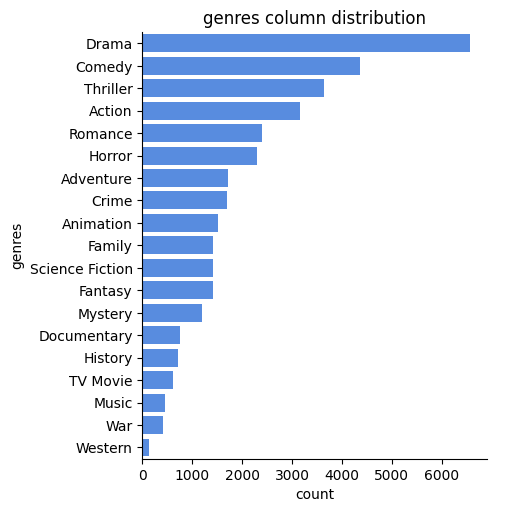

In [65]:
sns.catplot(y ='genres', data = df, kind = 'count',
            order = df['genres'].value_counts().index,
            color = '#4287f5')
plt.title('genres column distribution')
plt.show()

# Which has highest votes in vote avg column ?

In [66]:
df.head()

,show_id,Title,Director,Release_date,genres,popularity,vote_count,vote_average
0,10192,Shrek Forever After,Mike Mitchell,2010,Comedy,203.893,7449,average
1,10192,Shrek Forever After,Mike Mitchell,2010,Adventure,203.893,7449,average
2,10192,Shrek Forever After,Mike Mitchell,2010,Fantasy,203.893,7449,average
3,10192,Shrek Forever After,Mike Mitchell,2010,Animation,203.893,7449,average
4,10192,Shrek Forever After,Mike Mitchell,2010,Family,203.893,7449,average


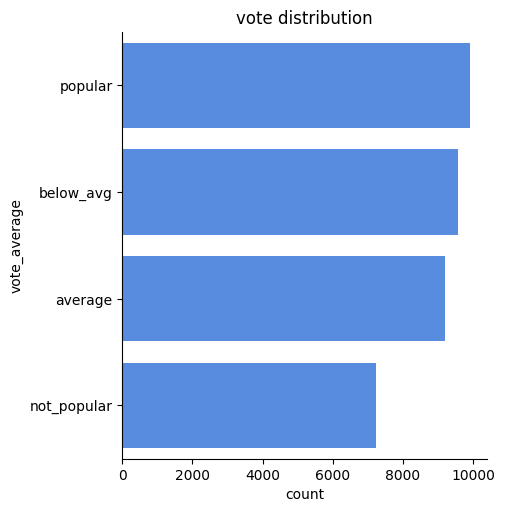

In [67]:
sns.catplot(y ='vote_average', data = df, kind= 'count',
            order= df['vote_average'].value_counts().index,
            color= '#4287f5')
plt.title('vote distribution')

plt.show()

 # what movie got the highest popularity? what's its genre.

In [68]:
df.head(2)

,show_id,Title,Director,Release_date,genres,popularity,vote_count,vote_average
0,10192,Shrek Forever After,Mike Mitchell,2010,Comedy,203.893,7449,average
1,10192,Shrek Forever After,Mike Mitchell,2010,Adventure,203.893,7449,average


In [69]:
df[df['popularity'] == df['popularity'].max()]

,show_id,Title,Director,Release_date,genres,popularity,vote_count,vote_average
35359,950396,The Gorge,Scott Derrickson,2025,Romance,3876.006,1572,popular
35360,950396,The Gorge,Scott Derrickson,2025,Science Fiction,3876.006,1572,popular
35361,950396,The Gorge,Scott Derrickson,2025,Thriller,3876.006,1572,popular


# What movie have lowest popularity?

In [70]:
df[df['popularity'] == df['popularity'].min()]

,show_id,Title,Director,Release_date,genres,popularity,vote_count,vote_average
2465,58884,Sympathy for Delicious,Mark Ruffalo,2010,Drama,3.86,34,below_avg


# which year has the most filmmed movies?

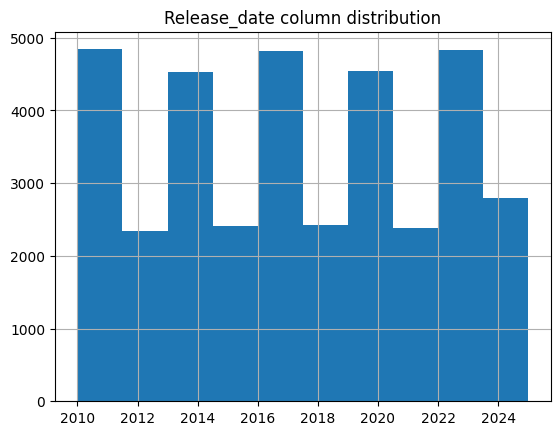

In [71]:
df['Release_date'].hist()
plt.title('Release_date column distribution')

plt.show()

# Conclusion

1. Most Frequent Genre: The most common genre of movie in this dataset is Drama.
2. Highest Count in Vote Average: When categorized, the 'below average' rating category contains the highest number of movies.
3. Highest Popularity: The movie with the highest popularity is 'The Gorge' from 2025, which includes Romance, Science Fiction, and Thriller genres.
4. Lowest Popularity: The movie with the lowest popularity is 'Sympathy for Delicious' from 2010, a Drama film.
5. Year with Most Movies: The year 2025 has the highest number of filmed movies in this dataset.